In [ ]:
Machine Learning
This code uses the dataset analysing it predicting outcomes based on user behavior,
optimizing conversion rates, and ranking items or users effectively.
Algorithms used:  Logistic regresion, decision trees, gradient boosting, and random forest.

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print ("done with the imports")

done with the imports


In [13]:
sns.set()

print ("sns set")

sns set


In [14]:
# 1) Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
cols = ["id", "diagnosis"] + [f"feat_{i}" for i in range(1, 31)]
df = pd.read_csv(url, header=None, names=cols)

print ("dataset ready")

dataset ready


In [15]:
# 2) Prepare features / target
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"].map({"M": 1, "B": 0})  # Malignant=1, Benign=0

# Quick EDA
print("Shape:", X.shape)
print(y.value_counts())


Shape: (569, 30)
diagnosis
0    357
1    212
Name: count, dtype: int64


In [17]:
# 3) Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print ("train/test complete")

train/test complete


In [18]:
# 4) Define models with pipelines (scaling for LR)
models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}


---LogisticRegression---
              precision    recall  f1-score   support

           0     0.9595    0.9861    0.9726        72
           1     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114

---DecisionTree---
              precision    recall  f1-score   support

           0     0.9444    0.9444    0.9444        72
           1     0.9048    0.9048    0.9048        42

    accuracy                         0.9298       114
   macro avg     0.9246    0.9246    0.9246       114
weighted avg     0.9298    0.9298    0.9298       114

---RandomForest---
              precision    recall  f1-score   support

           0     0.9474    1.0000    0.9730        72
           1     1.0000    0.9048    0.9500        42

    accuracy                         0.9649       114
   macro avg     0.9737    0.9524    0.9615       114
weighted av

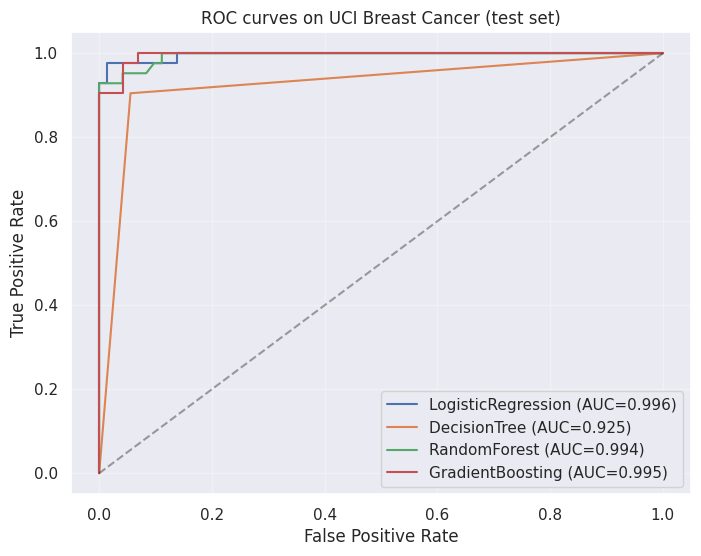

In [19]:
# 5) Train, evaluate, and collect metrics
results = []
plt.figure(figsize=(8,6))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # some models don't have predict_proba (all here do), use decision_function fallback
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_score)
    results.append((name, acc, roc))
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc:.3f})")
    print(f"---{name}---")
    print(classification_report(y_test, y_pred, digits=4))

plt.plot([0,1],[0,1],"k--",alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves on UCI Breast Cancer (test set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()



In [20]:
# 6) 5-fold stratified cross-validation (AUC) for each model
print("\n5-fold CV (ROC AUC) results:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    # for pipelines, cross_val_score handles scaling inside
    scores = cross_val_score(model, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
    print(f"{name}: mean AUC = {scores.mean():.4f} ± {scores.std():.4f}")



5-fold CV (ROC AUC) results:
LogisticRegression: mean AUC = 0.9953 ± 0.0053
DecisionTree: mean AUC = 0.9000 ± 0.0368
RandomForest: mean AUC = 0.9896 ± 0.0077
GradientBoosting: mean AUC = 0.9927 ± 0.0050


In [21]:
# 7) Show summary
summary_df = pd.DataFrame(results, columns=["model", "test_accuracy", "test_roc_auc"]).sort_values("test_roc_auc", ascending=False)
print("\nSummary (test set):")
print(summary_df)



Summary (test set):
                model  test_accuracy  test_roc_auc
0  LogisticRegression       0.964912      0.996032
3    GradientBoosting       0.964912      0.995370
2        RandomForest       0.964912      0.994213
1        DecisionTree       0.929825      0.924603
